In [1]:
import pandas as pd
import numpy as np

path_csv = "data/llm_pilot_data/final_data/historical_performance_data_enriched_final.csv"

targerts = ["throughput", "median_nttft", "median_itl"]
data = pd.read_csv(path_csv)


In [3]:
counts = data["model"].value_counts().sort_values(ascending=False)
print(counts)

model
google/flan-t5-xl          112
llama-7b                    80
google/flan-t5-xxl          72
bigcode/starcoder           64
llama-13b                   64
EleutherAI/gpt-neox-20b     56
google/flan-ul2             40
bigscience/mt0-xxl          16
ibm/mpt-7b-instruct2        16
Salesforce/codegen2-16B      8
Name: count, dtype: int64


In [4]:
total_n = len(data)

per_model = (
    data.groupby("model")
      .size()
      .rename("n_samples")
      .reset_index()
)

per_model["frac_%"] = per_model["n_samples"] / total_n * 100.0

# Largest to smallest
per_model = per_model.sort_values("n_samples", ascending=False)

print(per_model)
# Optionally save
per_model.to_csv("results/per_model_counts.csv", index=False)


                     model  n_samples     frac_%
4        google/flan-t5-xl        112  21.212121
9                 llama-7b         80  15.151515
5       google/flan-t5-xxl         72  13.636364
2        bigcode/starcoder         64  12.121212
8                llama-13b         64  12.121212
0  EleutherAI/gpt-neox-20b         56  10.606061
6          google/flan-ul2         40   7.575758
3       bigscience/mt0-xxl         16   3.030303
7     ibm/mpt-7b-instruct2         16   3.030303
1  Salesforce/codegen2-16B          8   1.515152


In [16]:
path_full = "data/llm_pilot_data/raw_data/performance_data_for_AIware_final.csv"
df = pd.read_csv(path_full)
df.shape, df.columns, df.head(3), df.dtypes

((812894, 53),
 Index(['Workload_smpnum', 'Workload_reqnum', 'AI_model', 'Workload_num_users',
        'Workload_requests', 'Target_latency_ms', 'records', 'NonAI_n_gpus',
        'NonAI_gpu_type', 'Target_experiment_duration_s',
        'Workload_n_input_tokens', 'Workload_n_output_tokens',
        'Target_latency_ms_per_token', 'Target_timestamps_per_token',
        'NonAI_gpu', 'AI_model_is_flash_attention', 'AI_model_n_parameters',
        'AI_model_is_encoder_decoder', 'AI_model_type', 'AI_model_n_positions',
        'AI_model_n_heads', 'AI_model_n_layers',
        'AI_model_relative_attention_max_distance',
        'AI_model_relative_attention_n_buckets', 'AI_model_torch_dtype',
        'AI_model_vocabulary_size', 'NonAI_gpu_architecture',
        'NonAI_gpu_n_tensor_cores', 'NonAI_gpu_n_rt_cores',
        'NonAI_gpu_n_cuda_cores', 'NonAI_gpu_n_sms', 'NonAI_gpu_n_rops',
        'NonAI_gpu_n_tmus', 'NonAI_gpu_tflops_cuda_mixed',
        'NonAI_gpu_tflops_cuda_fp32', 'NonAI_gpu_tfl

In [17]:
bool_cols = df.select_dtypes(include=["bool", "boolean"]).columns.tolist()

if bool_cols:
    df[bool_cols] = df[bool_cols].astype(int)
    print("[INFO] Converted boolean columns to 0/1:")
    for c in bool_cols:
        print(f"  - {c}")
else:
    print("[INFO] No boolean columns found.")

[INFO] Converted boolean columns to 0/1:
  - AI_model_is_flash_attention
  - AI_model_is_encoder_decoder
  - NonAI_gpu_is_sxm
  - NonAI_gpu_is_nvlink


In [19]:
# check again if still any boolean columns
bool_cols_check = df.select_dtypes(include=["bool", "boolean"]).columns.tolist()
if bool_cols_check:
    print("[WARNING] Some boolean columns still remain after conversion:")
    for c in bool_cols_check:
        print(f"  - {c}")
else:
    print("[INFO] All boolean columns successfully converted to 0/1.")

[INFO] All boolean columns successfully converted to 0/1.


In [20]:
# 4. Check missing values per column (before filling)
na_counts = df.isna().sum()
print("\n[INFO] Missing values per column (before fillna):")
print(na_counts[na_counts > 0].sort_values(ascending=False))



[INFO] Missing values per column (before fillna):
AI_model_relative_attention_max_distance    540111
AI_model_relative_attention_n_buckets       540111
AI_model_n_positions                        107714
dtype: int64


In [21]:
# 5. Fill all remaining missing values with -1
df = df.fillna(-1)


In [22]:
# 6. Sanity-check missing values after filling
na_after = df.isna().sum()
print("\n[INFO] Missing values per column (after fillna):")
print(na_after[na_after > 0])  # should print nothing



[INFO] Missing values per column (after fillna):
Series([], dtype: int64)


In [23]:
df.to_csv(
    "data/llm_pilot_data/final_data/full_raw_data_800k_clean.csv",
    index=False
)
print("\n[SAVED] Cleaned dataset with 0/1 booleans and NA=-1.")


[SAVED] Cleaned dataset with 0/1 booleans and NA=-1.


In [24]:


counts = df["AI_model"].value_counts().sort_values(ascending=False)
print(counts)

total_full_data = len(df)
print(f"Total full data samples: {total_full_data}")

per_model_full = (
    df.groupby("AI_model")
        .size()
        .rename("n_samples")
        .reset_index()
)
per_model_full["frac_%"] = per_model_full["n_samples"] / total_full_data * 100.0
per_model_full = per_model_full.sort_values("n_samples", ascending=False)
print(per_model_full)
per_model_full.to_csv("data/llm_pilot_data/raw_data/per_model_counts_full_data.csv", index=False)


AI_model
llama-7b                   171218
google/flan-t5-xl          138299
bigcode/starcoder          134772
llama-13b                  119291
EleutherAI/gpt-neox-20b     89719
google/flan-t5-xxl          77922
google/flan-ul2             45856
ibm/mpt-7b-instruct2        19086
bigscience/mt0-xxl          10706
Salesforce/codegen2-16B      6025
Name: count, dtype: int64
Total full data samples: 812894
                  AI_model  n_samples     frac_%
9                 llama-7b     171218  21.062771
4        google/flan-t5-xl     138299  17.013165
2        bigcode/starcoder     134772  16.579283
8                llama-13b     119291  14.674853
0  EleutherAI/gpt-neox-20b      89719  11.036986
5       google/flan-t5-xxl      77922   9.585752
6          google/flan-ul2      45856   5.641080
7     ibm/mpt-7b-instruct2      19086   2.347908
3       bigscience/mt0-xxl      10706   1.317023
1  Salesforce/codegen2-16B       6025   0.741179


In [25]:
df['Target_throughput_tokens_per_sec'].head(3)

0     125.597936
1    1129.112495
2      43.925213
Name: Target_throughput_tokens_per_sec, dtype: float64

In [26]:

groups = {name: g for name, g in df.groupby("AI_model")}

# Example: access the subset for a particular model
llama7b_df   = groups.get("llama-7b", None)
llama13b_df = groups.get("llama13b", None)


In [27]:
llama7b_df.head(3)


,Workload_smpnum,Workload_reqnum,AI_model,Workload_num_users,Workload_requests,Target_latency_ms,records,NonAI_n_gpus,NonAI_gpu_type,Target_experiment_duration_s,...,NonAI_gpu_system_interface_gen,NonAI_gpu_compute_capability,NonAI_gpu_is_sxm,NonAI_gpu_is_nvlink,NonAI_gpu_n_gpus,NonAI_gpu_memory_capacity_gb_total,Workload_sequence_length,Target_throughput_tokens_per_sec,Target_ITL,Target_TTFL
4745,753,0,llama-7b,128,1,2517.0,1.0,2,H100,120,...,5,9.0,1,1,2,160,103.0,40.921716,0.597162,125.849994
4746,371,0,llama-7b,128,1,1115.0,1.0,2,H100,120,...,5,9.0,1,1,2,160,14.0,12.556043,6.342989,1114.998885
4747,553,0,llama-7b,128,1,2612.0,1.0,2,H100,120,...,5,9.0,1,1,2,160,108.0,41.347611,0.584923,130.599993


In [28]:
output_dir = "data/llm_pilot_data/raw_data/per_model"

for ai_name, g in df.groupby("AI_model"):
    safe_name = str(ai_name).replace("/", "_").replace(" ", "_")
    out_path = f"{output_dir}/data_{safe_name}.csv"
    g.to_csv(out_path, index=False)


In [29]:
groups = df["AI_model"]
for name, g in df.groupby("AI_model"):
    print(name, len(g))


EleutherAI/gpt-neox-20b 89719
Salesforce/codegen2-16B 6025
bigcode/starcoder 134772
bigscience/mt0-xxl 10706
google/flan-t5-xl 138299
google/flan-t5-xxl 77922
google/flan-ul2 45856
ibm/mpt-7b-instruct2 19086
llama-13b 119291
llama-7b 171218


Run Monolithic single RF regression


=== Dataset: data_EleutherAI_gpt-neox-20b ===
  Fold 1/10: R2=0.995, MAE=14.239, RMSE=38.585, MRE=26.95%
  Fold 2/10: R2=0.992, MAE=15.839, RMSE=55.239, MRE=25.67%
  Fold 3/10: R2=0.997, MAE=13.695, RMSE=31.974, MRE=24.24%
  Fold 4/10: R2=0.994, MAE=14.937, RMSE=48.756, MRE=24.18%
  Fold 5/10: R2=0.996, MAE=15.203, RMSE=38.698, MRE=25.32%
  Fold 6/10: R2=0.996, MAE=13.870, RMSE=34.929, MRE=22.77%
  Fold 7/10: R2=0.994, MAE=14.137, RMSE=43.116, MRE=23.30%
  Fold 8/10: R2=0.995, MAE=14.298, RMSE=42.490, MRE=24.00%
  Fold 9/10: R2=0.996, MAE=15.506, RMSE=36.864, MRE=26.10%
  Fold 10/10: R2=0.989, MAE=15.590, RMSE=63.902, MRE=23.41%
  [MEAN] R2=0.994, MAE=14.731, RMSE=43.455, MRE=24.59%

=== Dataset: data_Salesforce_codegen2-16B ===
  Fold 1/10: R2=0.975, MAE=10.266, RMSE=65.727, MRE=19.09%
  Fold 2/10: R2=0.977, MAE=12.456, RMSE=64.469, MRE=22.91%
  Fold 3/10: R2=0.967, MAE=14.168, RMSE=79.343, MRE=21.64%
  Fold 4/10: R2=0.958, MAE=17.440, RMSE=98.947, MRE=17.26%
  Fold 5/10: R2=0.945, M

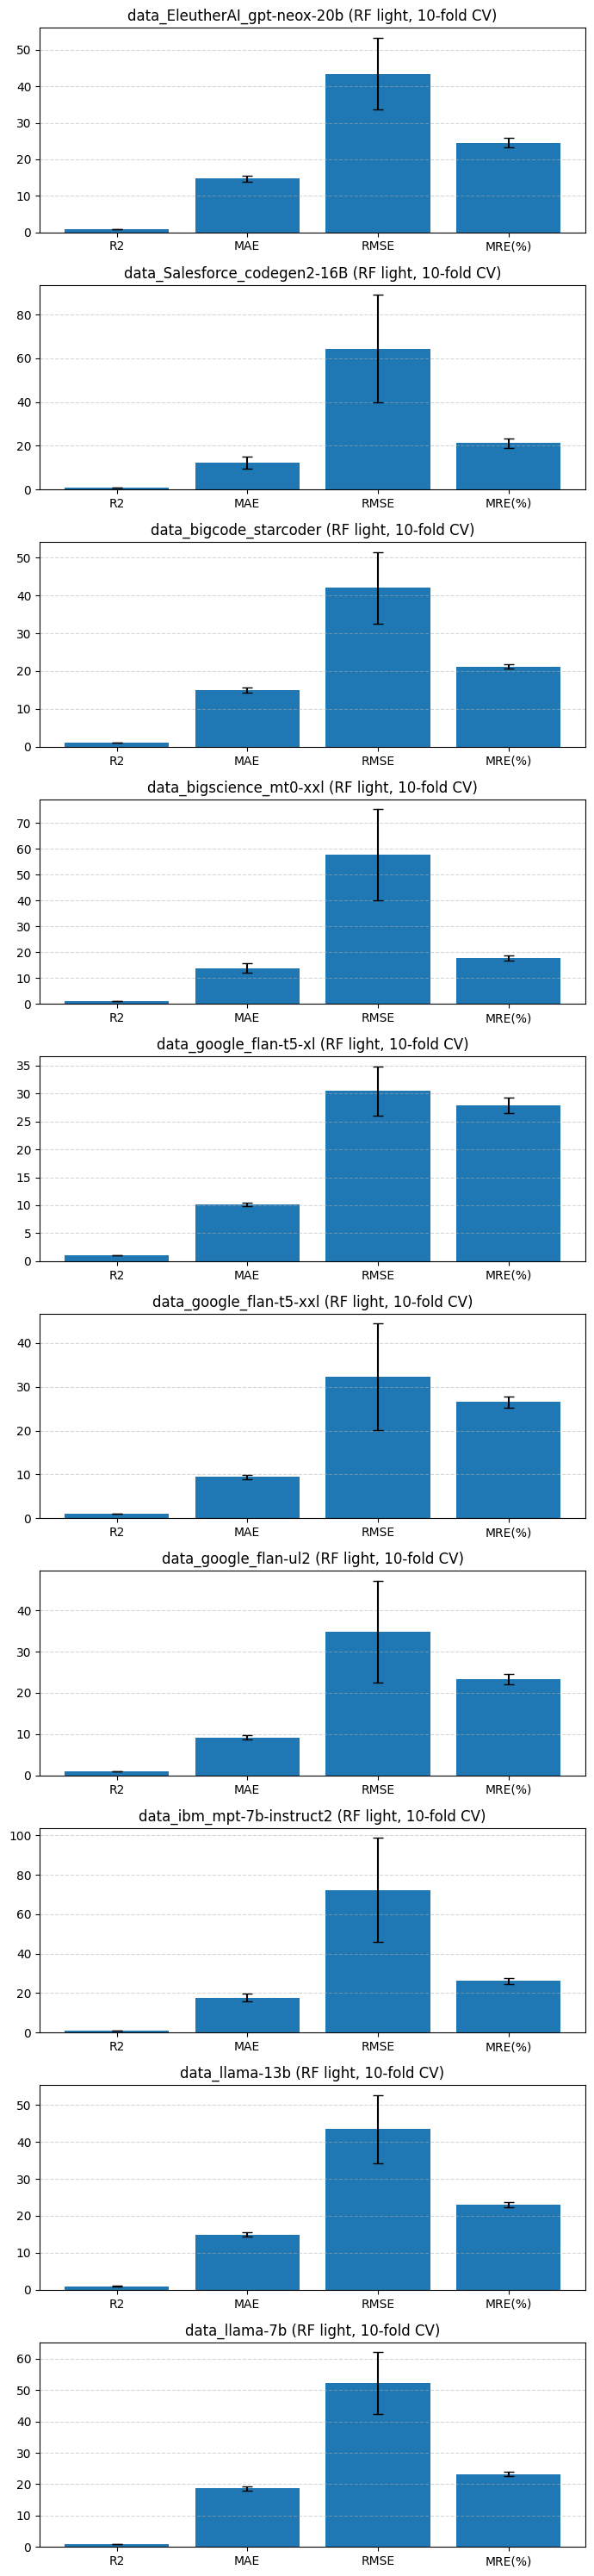


=== Summary across datasets ===
                     dataset  n_samples  mean_R2  mean_MAE  mean_RMSE  mean_MRE(%)   std_R2  std_MAE  std_RMSE  std_MRE(%)
data_EleutherAI_gpt-neox-20b      89719 0.994453 14.731459  43.455400    24.593194 0.002251 0.776541  9.890531    1.356892
data_Salesforce_codegen2-16B       6025 0.973733 12.270486  64.437178    21.188846 0.014727 2.767384 24.563784    2.108456
      data_bigcode_starcoder     134772 0.995274 14.890953  42.033483    21.148057 0.001779 0.693642  9.476576    0.574710
     data_bigscience_mt0-xxl      10706 0.987888 13.904727  57.691499    17.789815 0.005355 1.759417 17.605439    1.057250
      data_google_flan-t5-xl     138299 0.995029 10.116215  30.441100    27.926744 0.001216 0.281341  4.433422    1.381022
     data_google_flan-t5-xxl      77922 0.993027  9.391039  32.300078    26.502265 0.005928 0.565635 12.146636    1.305539
        data_google_flan-ul2      45856 0.991003  9.206237  34.820006    23.406108 0.006160 0.571184 12.39

In [30]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ----------------- CONFIG -----------------
output_dir = "data/llm_pilot_data/raw_data/per_model"
target_col = "Target_throughput_tokens_per_sec"

# "Light" RF config
def make_light_rf(seed: int = 42) -> RandomForestRegressor:
    return RandomForestRegressor(
        n_estimators=80,
        max_depth=10,
        min_samples_leaf=5,
        max_features="sqrt",
        n_jobs=-1,
        random_state=seed,
    )

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    eps = 1e-8
    mre = np.mean(
        np.abs(y_pred - y_true) / np.maximum(np.abs(y_true), eps)
    ) * 100.0

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MRE(%)": mre,
    }

# ----------------- MAIN LOOP -----------------
csv_files = sorted(glob.glob(os.path.join(output_dir, "*.csv")))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {output_dir}")

results = []

n_files = len(csv_files)
fig, axes = plt.subplots(
    nrows=n_files,
    ncols=1,
    figsize=(7, 3 * n_files),
    squeeze=False
)
axes = axes.ravel()

for idx, (ax, path) in enumerate(zip(axes, csv_files)):
    df = pd.read_csv(path)

    dataset_name = os.path.splitext(os.path.basename(path))[0]
    print(f"\n=== Dataset: {dataset_name} ===")

    # 1. Select numeric columns only
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if target_col not in numeric_cols:
        print(f"  [WARN] Target '{target_col}' not found as numeric in {dataset_name}. Skipping.")
        ax.set_visible(False)
        continue

    # 2. Define X, y
    feature_cols = [c for c in numeric_cols if c != target_col]
    if len(feature_cols) == 0:
        print(f"  [WARN] No numeric feature columns (besides target) in {dataset_name}. Skipping.")
        ax.set_visible(False)
        continue

    X = df[feature_cols].to_numpy()
    y = df[target_col].to_numpy()

    n_samples = len(df)
    n_splits = min(10, n_samples)
    if n_splits < 2:
        print(f"  [WARN] Not enough samples ({n_samples}) for CV in {dataset_name}. Skipping.")
        ax.set_visible(False)
        continue

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # 3. Run CV
    fold_metrics = []
    for fold, (tr, te) in enumerate(cv.split(X), 1):
        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]

        rf = make_light_rf(seed=42 + fold)
        rf.fit(X_tr, y_tr)
        y_pred = rf.predict(X_te)

        m = compute_metrics(y_te, y_pred)
        fold_metrics.append(m)

        print(
            f"  Fold {fold}/{n_splits}: "
            f"R2={m['R2']:.3f}, MAE={m['MAE']:.3f}, "
            f"RMSE={m['RMSE']:.3f}, MRE={m['MRE(%)']:.2f}%"
        )

    # 4. Aggregate metrics across folds
    df_folds = pd.DataFrame(fold_metrics)
    mean_metrics = df_folds.mean().to_dict()
    std_metrics = df_folds.std().to_dict()

    print("  [MEAN] R2={:.3f}, MAE={:.3f}, RMSE={:.3f}, MRE={:.2f}%".format(
        mean_metrics["R2"], mean_metrics["MAE"],
        mean_metrics["RMSE"], mean_metrics["MRE(%)"]
    ))

    results.append({
        "dataset": dataset_name,
        "n_samples": n_samples,
        **{f"mean_{k}": v for k, v in mean_metrics.items()},
        **{f"std_{k}": v for k, v in std_metrics.items()},
    })

    # 5. Plot per-dataset bar chart (mean ± std)
    metrics_order = ["R2", "MAE", "RMSE", "MRE(%)"]
    means = [mean_metrics[m] for m in metrics_order]
    errs = [std_metrics[m] for m in metrics_order]

    x = np.arange(len(metrics_order))

    ax.bar(x, means, yerr=errs, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_order)
    ax.set_title(f"{dataset_name} (RF light, {n_splits}-fold CV)")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 6. Summarise all datasets
results_df = pd.DataFrame(results)
print("\n=== Summary across datasets ===")
print(results_df.to_string(index=False))
result_dir = 'results/jupyter_results/per_model_splits'
# Optionally save:
results_df.to_csv(
    os.path.join(result_dir, "rf_light_throughput_cv_summary.csv"),
    index=False
)
print(f"\n[Saved] Summary to {os.path.join(result_dir, 'rf_light_throughput_cv_summary.csv')}")
